# Iris — a Tsetlin machine you can read

The Iris dataset is small, continuous and famously separable, which makes it the right place
to see what a Tsetlin machine (TM) actually *is*: not a set of weights, but a set of **logical
rules** built from Boolean literals.

This notebook covers the full workflow with `torchtsetlin`:

1. Load Iris (it ships with scikit-learn — torchvision has no tabular datasets).
2. **Booleanize** the four continuous measurements with a thermometer encoder.
3. Train a `TsetlinMachine` with the PyTorch-style `Trainer`.
4. **Evaluate**: accuracy, confusion matrix, per-class report, calibration, trustworthiness.
5. **Interpret**: read the learned rules, rank features, explain a single prediction.
6. Sweep the hyper-parameters that matter (`n_bits`, `s`, `T`, clause size) and compare
   against scikit-learn baselines.

### How a Tsetlin machine learns, in one paragraph

Every clause is an AND of *literals* — either a feature `x_k` or its negation `NOT x_k`. Each
(clause, literal) pair owns a **Tsetlin automaton**: an integer counter whose value decides
whether that literal is currently *included* in the clause. A clause outputs 1 when all of its
included literals are true. Clauses of the correct class receive **Type I** feedback (memorise
the literals that are true in this example, forget the rest); clauses of a randomly picked
wrong class receive **Type II** feedback (include a currently-false literal so the clause stops
matching). How often feedback happens is governed by the vote margin `T`; how specific the
resulting clauses are is governed by `s`. There is no gradient anywhere — which is why the
learnable state lives in integer *buffers*, not `nn.Parameter`s.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

import torchtsetlin as tt

SEED = 0
tt.seed_everything(SEED)

# Iris is tiny: the CPU is faster than a GPU here (no kernel-launch overhead).
device = torch.device("cpu")
print("torchtsetlin", tt.__version__, "| torch", torch.__version__, "| device", device)

torchtsetlin 0.1.1 | torch 2.10.0+cu128 | device cpu


## 1. The data

Four continuous measurements (sepal/petal length and width, in cm), three species, 150 samples.
We hold out 30 % as a stratified test set.

In [2]:
iris = load_iris()
X = iris.data.astype("float32")
y = iris.target.astype("int64")
feature_names = list(iris.feature_names)
class_names = [str(n) for n in iris.target_names]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
print(f"train {X_train.shape}  test {X_test.shape}  classes {class_names}")
print("\nfeature ranges (train):")
for i, n in enumerate(feature_names):
    print(f"  {n:<20s} {X_train[:, i].min():.1f} … {X_train[:, i].max():.1f}")

train (105, 4)  test (45, 4)  classes ['setosa', 'versicolor', 'virginica']

feature ranges (train):
  sepal length (cm)    4.3 … 7.9
  sepal width (cm)     2.0 … 4.4
  petal length (cm)    1.0 … 6.9
  petal width (cm)     0.1 … 2.5


## 2. Booleanization: the thermometer encoder

A Tsetlin machine only consumes **Boolean** features, so continuous measurements have to be
discretised. The naive choice — one-hot binning — throws away the ordering: nothing tells the
machine that `2.5 cm` is closer to `3.0 cm` than to `6.0 cm`.

A **thermometer** (ordinal) encoding keeps the ordering. Each feature `v` becomes `n_bits`
Booleans

```
[v >= t1, v >= t2, ..., v >= tn]   with t1 < t2 < ... < tn
```

so the bits switch on progressively, like mercury rising. The pay-off is that a clause can
express an *interval* with just two literals:

```
(petal length >= 3.0) AND NOT (petal length >= 4.9)   ==   3.0 <= petal length < 4.9
```

`ThermometerEncoder` follows the scikit-learn `fit`/`transform` protocol. We fit it on the
**training split only** — the thresholds are quantiles of the data, so fitting on the test set
would leak information.

In [3]:
N_BITS = 8

encoder = tt.data.ThermometerEncoder(n_bits=N_BITS, strategy="quantile")
encoder.fit(torch.from_numpy(X_train))                      # thresholds = per-feature quantiles

x_train = encoder.transform(torch.from_numpy(X_train)).to(device)
x_test = encoder.transform(torch.from_numpy(X_test)).to(device)
y_train_t = torch.from_numpy(y_train).to(device)
y_test_t = torch.from_numpy(y_test).to(device)

# Readable names for every Boolean feature, e.g. "petal length (cm)>=4.9".
bool_names = encoder.feature_names(feature_names)

print(f"{X_train.shape[1]} continuous features -> {x_train.shape[1]} Boolean features "
      f"({X_train.shape[1]} x {N_BITS} bits), dtype={x_train.dtype}")
print("\nthresholds for", feature_names[2])
print(np.round(encoder.thresholds[2].numpy(), 2))

4 continuous features -> 32 Boolean features (4 x 8 bits), dtype=torch.bool

thresholds for petal length (cm)
[1.4  1.5  2.57 4.   4.5  4.9  5.29 5.74]


raw: {'sepal length (cm)': np.float32(6.7), 'sepal width (cm)': np.float32(3.3), 'petal length (cm)': np.float32(5.7), 'petal width (cm)': np.float32(2.5)} -> virginica

  sepal length (cm)     6.70  ->  [1, 1, 1, 1, 1, 1, 1, 0]
  sepal width (cm)      3.30  ->  [1, 1, 1, 1, 1, 1, 0, 0]
  petal length (cm)     5.70  ->  [1, 1, 1, 1, 1, 1, 1, 0]
  petal width (cm)      2.50  ->  [1, 1, 1, 1, 1, 1, 1, 1]


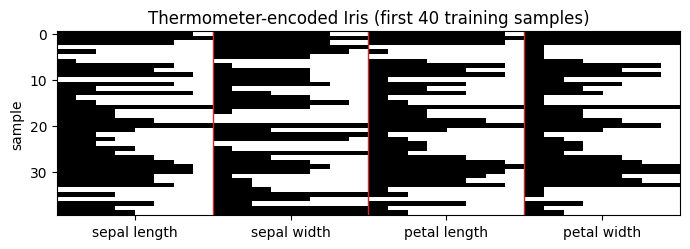

In [4]:
# What one flower looks like after encoding.
i = 0
print("raw:", dict(zip(feature_names, X_train[i])), "->", class_names[y_train[i]])
print()
for f, name in enumerate(feature_names):
    bits = x_train[i, f * N_BITS:(f + 1) * N_BITS].int().tolist()
    print(f"  {name:<20s} {X_train[i, f]:5.2f}  ->  {bits}")

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.imshow(x_train[:40].numpy(), aspect="auto", cmap="Greys", interpolation="nearest")
for f in range(1, 4):
    ax.axvline(f * N_BITS - 0.5, color="tab:red", lw=1)
ax.set_xticks([f * N_BITS + N_BITS / 2 - 0.5 for f in range(4)],
              [n.replace(" (cm)", "") for n in feature_names])
ax.set_ylabel("sample")
ax.set_title("Thermometer-encoded Iris (first 40 training samples)")
plt.tight_layout()
plt.show()

The staircase pattern is the thermometer at work: within each feature block the bits fill in
from the left as the measurement grows. The three species appear as three horizontal bands —
a hint that this problem is easy.

## 3. The model

`TsetlinMachine` is an ordinary `torch.nn.Module`. The hyper-parameters that matter:

| argument | meaning | effect |
|---|---|---|
| `n_clauses` | clauses **per class** | capacity; half vote *for* the class, half *against* it |
| `T` | vote margin | how many clauses must agree before feedback stops — larger `T` spreads the work over more clauses |
| `s` | specificity | memorise with prob. `(s-1)/s`, forget with prob. `1/s`; larger `s` -> more literals per clause -> more specific rules |
| `n_states` | automaton depth | memory: how much evidence it takes to flip a literal in or out |
| `weighted` | integer clause weights | lets one clause carry the vote of many duplicates (cheaper than more clauses) |
| `max_included_literals` | clause size budget | caps rule length — the single most useful knob for readability |

Iris needs almost nothing: 20 clauses per class is plenty.

In [5]:
model = tt.TsetlinMachine(
    n_features=x_train.shape[1],
    n_classes=3,
    n_clauses=20,               # per class
    T=15,
    s=10.0,
    n_states=100,
    weighted=True,
    max_included_literals=8,    # keep the rules short enough to read
).to(device)

# Attach names so rules() and explain() print something human.
model.feature_names = bool_names
model.class_names = class_names

print(model)
print("\nthe learnable state is a buffer, not a parameter:")
print("  ta_state", tuple(model.ta_state.shape), model.ta_state.dtype,
      "=", model.n_clauses_total, "clauses x", model.n_literals, "literals")

TsetlinMachine(n_classes=3, n_clauses_per_class=20, T=15.0, weighted=True, n_features=32, n_clauses_total=60, n_states=100, s=10.0, max_included_literals=8)

the learnable state is a buffer, not a parameter:
  ta_state (60, 64) torch.int32 = 60 clauses x 64 literals


### The raw learning step

Before reaching for the `Trainer`, here is the entire learning API. `model.update(x, y)` is the
Tsetlin analogue of `loss.backward(); optimizer.step()` — and it returns the vote sums computed
*before* the update, so you can log batch metrics without a second forward pass.

In [6]:
demo = tt.TsetlinMachine(x_train.shape[1], 3, n_clauses=20, T=15, s=10.0, n_states=100,
                         weighted=True, max_included_literals=8).to(device)
demo.train()
for epoch in range(40):
    perm = torch.randperm(x_train.shape[0])
    for i in range(0, len(perm), 8):
        idx = perm[i:i + 8]
        demo.update(x_train[idx], y_train_t[idx])

demo.eval()                                     # <- matters: see the note below
acc = (demo(x_test).argmax(1) == y_test_t).float().mean()
print(f"plain loop, 40 epochs: test accuracy {acc:.4f}")

plain loop, 40 epochs: test accuracy 1.0000


> **`train()` / `eval()` changes the predictions.** A clause with no included literals is
> treated as `True` while learning (so it can still receive feedback and grow) and as `False`
> when predicting (an empty rule should not vote). `forward()` keys this off `self.training`,
> exactly like dropout or batch-norm — so always call `model.eval()` before measuring
> anything. `Trainer` handles this for you.

## 4. Training with the `Trainer`

The `Trainer` adds batching, validation, callbacks and a `History`, and accepts tensors, a
`Dataset` or a `DataLoader`.

In [7]:
tt.seed_everything(SEED)
model.reset_parameters()

trainer = tt.Trainer(
    model,
    batch_size=8,
    callbacks=[
        tt.EarlyStopping(monitor="val_accuracy", patience=25, restore_best=True),
        tt.StateSummaryLogger(),        # logs mean clause length each epoch
    ],
    verbose=False,
)

history = trainer.fit(
    (x_train, y_train_t),
    epochs=80,
    val_data=(x_test, y_test_t),
)

best_acc, _ = history.best("val_accuracy")
stopped = any(e.get("early_stopped") for e in history.epochs)
print(f"{len(history)} epochs run{' (early stopped)' if stopped else ''} | "
      f"best val accuracy {best_acc:.4f}")
history.to_dataframe().tail(5)

40 epochs run (early stopped) | best val accuracy 1.0000


,epoch_time,batch_accuracy,val_accuracy,included_literals_mean,empty_clauses,early_stopped
35,0.009802,0.961905,1.000000,4.116667,1,NaN
36,0.009813,0.961905,1.000000,4.016667,1,NaN
37,0.009850,0.952381,0.977778,4.133333,1,NaN
38,0.009831,0.971429,1.000000,4.116667,2,NaN
39,0.009830,0.961905,1.000000,4.166667,2,True


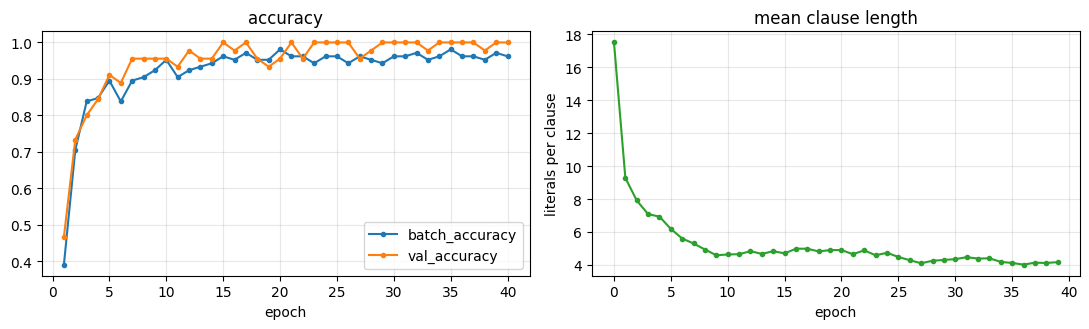

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
tt.viz.plot_history(history, metrics=["batch_accuracy", "val_accuracy"], ax=axes[0])
axes[0].set_title("accuracy")
axes[1].plot(history["included_literals_mean"], marker=".", color="tab:green")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("literals per clause")
axes[1].set_title("mean clause length"); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

Two things to notice. Accuracy rises within a handful of epochs — with 105 training samples and
a batch size of 8 that is only ~100 updates. And the mean clause length climbs from 0 (every
automaton starts just below the include boundary, so every clause is empty) and then settles:
the machine adds literals until clauses are specific enough to stop receiving Type I feedback.

## 5. Evaluation

`Trainer.evaluate` returns the task-appropriate metrics; `torchtsetlin.metrics` has the rest.

In [9]:
print(trainer.evaluate((x_test, y_test_t)))
print(trainer.evaluate((x_train, y_train_t), prefix="train_"))

model.eval()
votes = model(x_test)                 # (B, 3) vote sums, clamped to [-T, T]
pred = votes.argmax(1)

cm = tt.metrics.confusion_matrix(votes, y_test_t, n_classes=3)
print()
print(tt.metrics.classification_report(votes, y_test_t, class_names))

{'accuracy': 1.0}
{'train_accuracy': 0.9523809552192688}

            precision  recall  f1-score  support
setosa      1.000      1.000   1.000     15
versicolor  1.000      1.000   1.000     15
virginica   1.000      1.000   1.000     15

accuracy    1.000
macro avg   1.000      1.000   1.000     45


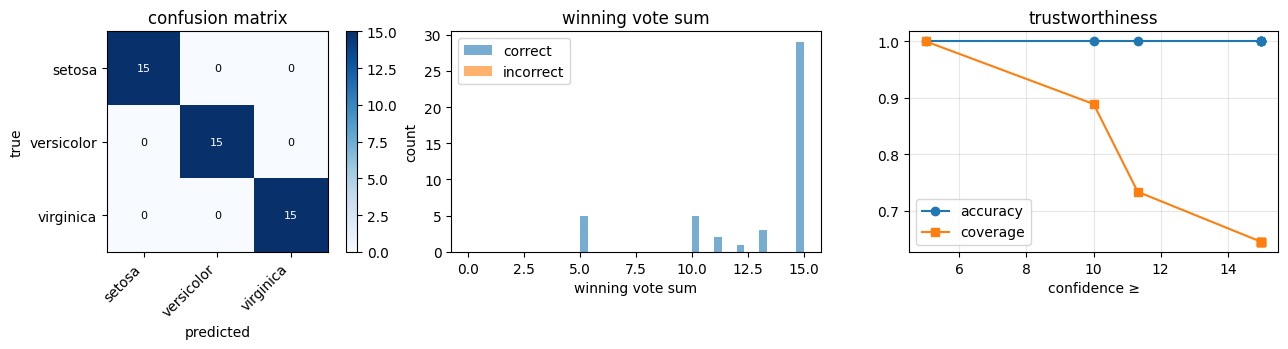

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
tt.viz.plot_confusion_matrix(cm, class_names, ax=axes[0])
axes[0].set_title("confusion matrix")

tt.viz.plot_votes(votes, y_test_t, ax=axes[1])
axes[1].set_title("winning vote sum")

curve = tt.metrics.trustworthiness_curve(votes, y_test_t, n_levels=8)
tt.viz.plot_trustworthiness(curve, ax=axes[2])
axes[2].set_title("trustworthiness")
plt.tight_layout()
plt.show()

### Reading the vote sums

A TM classifies by `argmax` over per-class vote sums, each clamped to `[-T, T]`. The **margin**
between the best and second-best sum is a natural confidence signal, and it is honest: the
trustworthiness curve above shows accuracy as a function of the confidence threshold, together
with the coverage you keep. A model is *trustworthy* when that curve rises monotonically — you
can abstain on low-confidence cases and buy accuracy.

In [11]:
margin = tt.metrics.vote_margin(votes)
proba = model.predict_proba(x_test)                    # calibrated linear score (1 + v/T)/2
correct = (pred == y_test_t)

print(f"mean vote margin on correct predictions: {margin[correct].mean():.2f}")
if (~correct).any():
    print(f"mean vote margin on errors:              {margin[~correct].mean():.2f}")
print(f"expected calibration error: {tt.metrics.expected_calibration_error(proba, y_test_t):.4f}")

# Abstain on the least confident 10 % of the test set.
keep = margin >= torch.quantile(margin.float(), 0.10)
print(f"accuracy at 100% coverage: {correct.float().mean():.4f}")
print(f"accuracy at  {keep.float().mean():.0%} coverage: {correct[keep].float().mean():.4f}")

mean vote margin on correct predictions: 23.49
expected calibration error: 0.1214
accuracy at 100% coverage: 1.0000
accuracy at  91% coverage: 1.0000


## 6. Interpretation — what did it actually learn?

This is the part a neural network cannot do. Every clause is a readable conjunction, and the
thermometer bits translate straight back into intervals on the original measurements.

In [12]:
def top_clauses(model, class_index, k=3, polarity=1):
    """Indices of the k highest-weight non-empty clauses of one class."""
    mask = ((model.clause_class == class_index) & (model.clause_polarity == polarity)
            & (model.include_count > 0) & (model.weights > 0))
    idx = torch.nonzero(mask).flatten()
    return idx[model.weights[idx].argsort(descending=True)][:k].tolist()


# The rules that vote FOR each class, strongest (highest weight) first.
for k, name in enumerate(class_names):
    print(f"=== {name} ===")
    for j in top_clauses(model, k):
        print(f"  [weight {int(model.weights[j]):2d}] IF {model.clause_expression(j, bool_names)}")
    print()

=== setosa ===
  [weight 10] IF sepal width (cm)>=3 AND NOT sepal length (cm)>=5.4 AND NOT sepal length (cm)>=6.3 AND NOT sepal length (cm)>=6.5 AND NOT sepal length (cm)>=6.844 AND NOT petal length (cm)>=4.9 AND NOT petal length (cm)>=5.289 AND NOT petal width (cm)>=0.8667 AND NOT petal width (cm)>=2.2
  [weight 10] IF sepal length (cm)>=5 AND sepal width (cm)>=2.711 AND sepal width (cm)>=3 AND petal length (cm)>=1.4 AND petal width (cm)>=0.2 AND NOT sepal length (cm)>=6.844 AND NOT petal length (cm)>=4 AND NOT petal length (cm)>=4.5 AND NOT petal length (cm)>=4.9 AND NOT petal length (cm)>=5.289 AND NOT petal width (cm)>=0.8667 AND NOT petal width (cm)>=1.4
  [weight  8] IF sepal width (cm)>=3 AND sepal width (cm)>=3.389 AND NOT sepal length (cm)>=6.844 AND NOT petal length (cm)>=1.5 AND NOT petal length (cm)>=4 AND NOT petal length (cm)>=4.9 AND NOT petal length (cm)>=5.744 AND NOT petal width (cm)>=1.222 AND NOT petal width (cm)>=1.633 AND NOT petal width (cm)>=2.2

=== versicolor 

Those rules are literal-for-literal what the machine computes, but the thermometer bits are
verbose. Because the bits of one feature are ordered, a set of included bits collapses to a
single interval — `decode_range` does exactly that, turning a clause back into a statement
about centimetres.

In [13]:
def clause_as_intervals(model, encoder, clause, feature_names, n_bits):
    """Collapse a clause's thermometer literals into per-feature intervals."""
    lits = model.clause_literals(clause)
    parts = []
    for f, name in enumerate(feature_names):
        lo_bits = [k - f * n_bits for k in lits["positive"] if f * n_bits <= k < (f + 1) * n_bits]
        hi_bits = [k - f * n_bits for k in lits["negated"] if f * n_bits <= k < (f + 1) * n_bits]
        if not lo_bits and not hi_bits:
            continue
        lo, hi = encoder.decode_range(f, lo_bits, hi_bits)
        short = name.replace(" (cm)", "")
        if lo == -np.inf:
            parts.append(f"{short} < {hi:.2f}")
        elif hi == np.inf:
            parts.append(f"{short} >= {lo:.2f}")
        else:
            parts.append(f"{lo:.2f} <= {short} < {hi:.2f}")
    return " AND ".join(parts) if parts else "TRUE"


# The same clauses as above, now read as intervals in centimetres.
for k, name in enumerate(class_names):
    j = top_clauses(model, k, 1)[0]
    print(f"{name:<12s} (clause {j}, weight {int(model.weights[j])}, "
          f"{int(model.include_count[j])} literals)")
    print(f"     IF {clause_as_intervals(model, encoder, j, feature_names, N_BITS)}\n")

setosa       (clause 1, weight 10, 9 literals)
     IF sepal length < 5.40 AND sepal width >= 3.00 AND petal length < 4.90 AND petal width < 0.87

versicolor   (clause 22, weight 10, 5 literals)
     IF sepal length >= 5.00 AND 2.57 <= petal length < 4.90

virginica    (clause 43, weight 8, 5 literals)
     IF sepal length >= 6.00 AND sepal width >= 3.00 AND petal length >= 4.90 AND petal width >= 1.63



Compare that with the textbook description of Iris: *setosa* is separated by a short petal,
*virginica* by a long/wide one, *versicolor* sits in between. The machine rediscovered the
petal measurements on its own — and it says so in centimetres.

### Which features matter?

`global_feature_importance` is the closed-form measure of Blakely & Granmo (2020): per class,
how much of the positive clause weight rests on each literal. Since each original feature owns
`n_bits` consecutive Boolean features, we aggregate the literals back into the four
measurements.

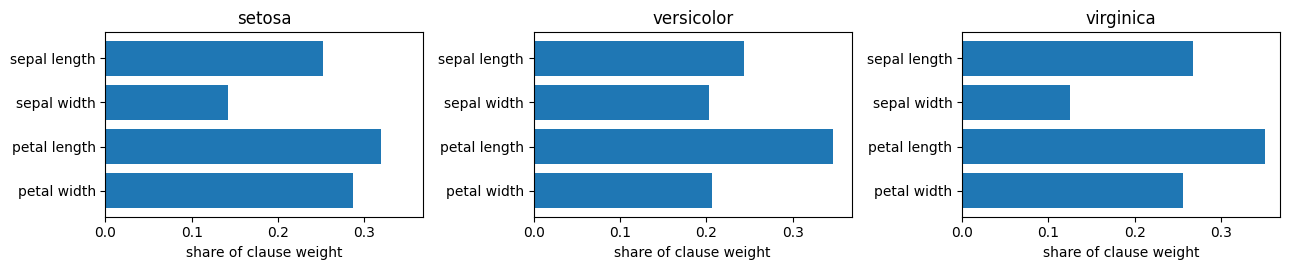

56/60 clauses fire on the test set | mean precision 0.979


In [14]:
groups = np.repeat(np.arange(len(feature_names)), N_BITS).tolist()
importance = tt.interpret.global_feature_importance(model)           # (3, 2F)

fig, axes = plt.subplots(1, 3, figsize=(13, 2.8), sharex=True)
for k, ax in enumerate(axes):
    agg = tt.interpret.aggregate_literal_importance(importance[k], groups, len(feature_names))
    ax.barh(range(4)[::-1], agg.numpy(), color="tab:blue")
    ax.set_yticks(range(4)[::-1], [n.replace(" (cm)", "") for n in feature_names])
    ax.set_title(class_names[k])
    ax.set_xlabel("share of clause weight")
plt.tight_layout()
plt.show()

# How reliable is each clause on held-out data?
prec = tt.interpret.clause_precision(model, x_test, y_test_t)
used = prec["support"] > 0
print(f"{int(used.sum())}/{model.n_clauses_total} clauses fire on the test set | "
      f"mean precision {prec['precision'][used].mean():.3f}")

### Explaining one prediction

`explain` lists the clauses that matched a single example and how much each contributed.

In [15]:
i = int(torch.nonzero(y_test_t == 2).flatten()[0])       # a virginica
print("measurements:", {n.replace(' (cm)', ''): float(v) for n, v in zip(feature_names, X_test[i])})
print("true:", class_names[y_test[i]], "| predicted:", class_names[int(pred[i])])
print()

expl = tt.interpret.explain(model, x_test[i], feature_names=bool_names, max_clauses=3)
print(f"votes {[round(v, 1) for v in expl.votes]}")
for m in expl.matched:
    print(f"  weight {m.weight:+.0f}: IF {clause_as_intervals(model, encoder, m.clause, feature_names, N_BITS)}")

measurements: {'sepal length': 6.300000190734863, 'sepal width': 3.4000000953674316, 'petal length': 5.599999904632568, 'petal width': 2.4000000953674316}
true: virginica | predicted: virginica

votes [-15.0, -8.0, 15.0]
  weight +8: IF sepal length >= 6.00 AND sepal width >= 3.00 AND petal length >= 4.90 AND petal width >= 1.63
  weight +5: IF petal length >= 4.00 AND petal width >= 1.63
  weight +4: IF sepal length >= 4.90 AND petal length >= 5.29


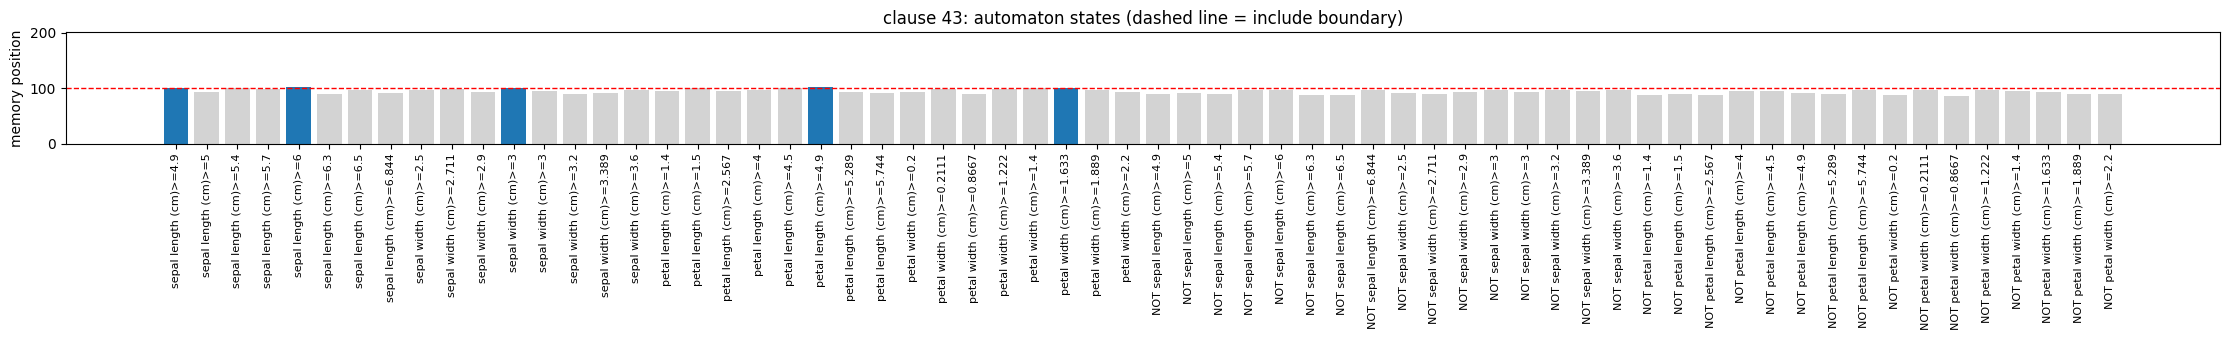

In [16]:
# The automata behind one clause: every bar is a literal, blue = included (memorised).
j = expl.matched[0].clause
tt.viz.plot_clause_memory(model, j, feature_names=bool_names)
plt.title(f"clause {j}: automaton states (dashed line = include boundary)")
plt.tight_layout()
plt.show()

## 7. What the hyper-parameters do

Iris trains in under a second, so we can afford an honest sweep — three seeds per setting,
reporting the mean test accuracy and the mean clause length.

In [17]:
import itertools
import pandas as pd


def run_config(n_bits=8, n_clauses=20, T=15, s=10.0, max_lit=8, weighted=True,
               epochs=60, seeds=(0, 1, 2)):
    accs, lengths = [], []
    for seed in seeds:
        tt.seed_everything(seed)
        enc = tt.data.ThermometerEncoder(n_bits=n_bits, strategy="quantile")
        enc.fit(torch.from_numpy(X_train))
        xtr, xte = enc(torch.from_numpy(X_train)), enc(torch.from_numpy(X_test))
        m = tt.TsetlinMachine(xtr.shape[1], 3, n_clauses, T=T, s=s, n_states=100,
                              weighted=weighted, max_included_literals=max_lit)
        tr = tt.Trainer(m, batch_size=8, verbose=False)
        tr.fit((xtr, y_train_t), epochs=epochs)
        accs.append(tr.evaluate((xte, y_test_t))["accuracy"])
        lengths.append(m.state_summary()["included_literals_mean"])
    return float(np.mean(accs)), float(np.std(accs)), float(np.mean(lengths))


rows = []
for n_bits in (4, 8, 12):
    for s in (2.0, 3.9, 10.0):
        acc, std, length = run_config(n_bits=n_bits, s=s)
        rows.append({"n_bits": n_bits, "s": s, "accuracy": round(acc, 4),
                     "±": round(std, 4), "literals/clause": round(length, 1)})
sweep = pd.DataFrame(rows)
sweep.pivot(index="n_bits", columns="s", values="accuracy")

s,2.0,3.9,10.0
n_bits,,,
4,0.9333,0.9481,0.9556
8,0.9852,0.9852,0.9778
12,0.9481,0.9704,0.9778


In [18]:
rows = []
for weighted in (True, False):
    for max_lit in (2, 4, 8, None):
        acc, std, length = run_config(max_lit=max_lit, weighted=weighted)
        rows.append({"weighted": weighted, "max_included_literals": str(max_lit),
                     "accuracy": round(acc, 4), "±": round(std, 4),
                     "literals/clause": round(length, 1)})
pd.DataFrame(rows)

,weighted,max_included_literals,accuracy,±,literals/clause
0,True,2,0.9259,0.0583,2.5
1,True,4,0.9556,0.0181,3.4
2,True,8,0.9778,0.0314,4.8
3,True,None,0.9852,0.0105,6.3
4,False,2,0.9704,0.0277,3.3
5,False,4,0.9926,0.0105,5.4
6,False,8,0.9926,0.0105,9.2
7,False,None,0.6148,0.0637,25.2


In [19]:
rows = []
for n_clauses in (4, 10, 20, 50):
    acc, std, length = run_config(n_clauses=n_clauses)
    rows.append({"n_clauses (per class)": n_clauses, "accuracy": round(acc, 4),
                 "±": round(std, 4), "literals/clause": round(length, 1)})
for T in (5, 15, 40):
    acc, std, length = run_config(T=T)
    rows.append({"n_clauses (per class)": f"(T={T})", "accuracy": round(acc, 4),
                 "±": round(std, 4), "literals/clause": round(length, 1)})
pd.DataFrame(rows)

,n_clauses (per class),accuracy,±,literals/clause
0,4,0.9037,0.0210,3.1
1,10,0.9481,0.0105,4.1
2,20,0.9778,0.0314,4.8
3,50,0.9852,0.0210,4.5
4,(T=5),0.9630,0.0210,4.2
5,(T=15),0.9778,0.0314,4.8
6,(T=40),0.9704,0.0210,5.2


Reading the sweep:

* **`n_bits` is a resolution knob.** Too few bits and no clause can express a tight enough
  interval; too many and each extra threshold is one more literal to learn from 105 samples.
* **`s` trades specificity for generality.** Small `s` forgets aggressively and produces short,
  broad clauses; large `s` keeps literals and produces long, specific ones. On Iris the effect
  is mild — at 8 bits all three values land within noise of each other. It matters most when the
  encoding is coarse: at 4 bits the extra literals a large `s` retains partly compensate for the
  resolution the thresholds threw away.
* **`max_included_literals` and `weighted` interact, and the table shows it.** With integer
  weights the cap is close to free — a couple of accuracy points at most — and it shortens the
  rules. Without weights, leaving clauses uncapped at `s=10` is a real failure mode: clauses
  keep absorbing literals, become over-specific, match nothing, and accuracy collapses. Either
  cap the clause size or turn on `weighted` (or both).
* **Clause count saturates, `T` should scale with it.** Iris does not need 50 clauses per class;
  the extras learn duplicates, which is exactly what the integer weights are there to absorb.
  `T` is the number of votes that must agree before feedback stops, so a tiny `T` with many
  clauses leaves most of them idle.

## 8. Baselines and saving

For context, two scikit-learn models on the same split. The point is not that the TM wins — on
Iris everything wins — but that it lands in the same range *while producing rules*.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text

baselines = {
    "LogisticRegression": LogisticRegression(max_iter=500).fit(X_train, y_train),
    "DecisionTree(depth=3)": DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train, y_train),
}
print(f"{'model':<24s} test accuracy")
for name, clf in baselines.items():
    print(f"{name:<24s} {clf.score(X_test, y_test):.4f}")
print(f"{'TsetlinMachine':<24s} {float(correct.float().mean()):.4f}   "
      f"({int(model.n_clauses_total)} clauses, "
      f"{model.state_summary()['included_literals_mean']:.1f} literals each)")

print("\nthe decision tree, for comparison:")
print(export_text(baselines["DecisionTree(depth=3)"], feature_names=feature_names))

model                    test accuracy
LogisticRegression       1.0000
DecisionTree(depth=3)    0.9556
TsetlinMachine           1.0000   (60 clauses, 4.8 literals each)

the decision tree, for comparison:
|--- petal width (cm) <= 0.80
|   |--- class: 0
|--- petal width (cm) >  0.80
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 1
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



A depth-3 tree is also readable, but it partitions space with a single hierarchy of splits. The
TM learns 60 independent conjunctions that *vote*, so it degrades gracefully: no single wrong
split at the root can sink a prediction, and the per-class vote margin tells you when the
evidence is thin.

In [21]:
# Saving is plain PyTorch: the automata and clause weights are buffers in the state_dict.
torch.save({"model": model.state_dict(), "encoder": encoder.state_dict()}, "iris_tm.pt")

ckpt = torch.load("iris_tm.pt", weights_only=True)
restored = tt.TsetlinMachine(x_train.shape[1], 3, 20, T=15, s=10.0, n_states=100,
                             weighted=True, max_included_literals=8)
restored.load_state_dict(ckpt["model"])
restored.eval()
print("restored model matches:", bool((restored(x_test).argmax(1) == pred).all()))

restored model matches: True


## Takeaways

* **Booleanization is the modelling decision.** A thermometer encoding keeps the ordering of a
  continuous feature and lets a two-literal clause express an interval. `n_bits` sets the
  resolution the machine can ever reach — it is as important as any TM hyper-parameter.
* **`update()` is the whole learning API**; `Trainer` is convenience on top. Remember
  `model.eval()` before you measure anything.
* **The rules are the model.** `rules()`, `explain()` and `global_feature_importance()` read the
  same automata that produce the predictions — there is no surrogate, no post-hoc approximation.
* **Cap clause length.** `max_included_literals` is usually free in accuracy and transforms
  readability.

Next: [`02_mnist_tsetlin.ipynb`](02_mnist_tsetlin.ipynb) scales this up to images and introduces
the convolutional Tsetlin machine.